In [11]:
import numpy as np
import pandas as pd
import math
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, chi2_contingency, zscore, f_oneway, pearsonr, spearmanr, normaltest, levene, mannwhitneyu, ttest_ind
from statsmodels.stats.oneway import anova_oneway

import statsmodels.api as sm
from statsmodels.formula.api import ols

import plotly.express as px

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")

In [2]:
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")



engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)

In [3]:
tables = [
    'champ', 'mvp', 'player_advance', 'player_season_stats', 'players', 
    'seasons', 'team_season_stats', 'teams'
]

try:
    for table in tables:
        df_name = f"{table}"
        
        globals()[df_name] = pd.read_sql_table(table, con=engine)
        
        rows, cols = globals()[df_name].shape
        print(f"{df_name:<22} | Shape: {rows:<6} rows, {cols:<3} columns")

except Exception as e:
    print(f"Error loading tables: {e}")

champ                  | Shape: 7      rows, 3   columns
mvp                    | Shape: 81     rows, 11  columns
player_advance         | Shape: 3421   rows, 29  columns
player_season_stats    | Shape: 4513   rows, 25  columns
players                | Shape: 1172   rows, 12  columns
seasons                | Shape: 7      rows, 2   columns
team_season_stats      | Shape: 210    rows, 32  columns
teams                  | Shape: 30     rows, 12  columns


In [5]:
teams.head()

,team_id,team_name,from_year,to_year,total_games,total_wins,total_losses,playoffs,conference_championships,division_championships,championships,league
0,1,Atlanta Hawks,1949,2025,6102,3013,3088,50,0,13,1,NBA
1,2,Boston Celtics,1946,2025,6278,3751,2527,63,11,36,18,NBA/BAA
2,3,Brooklyn Nets,1967,2025,4776,2074,2702,31,2,5,2,NBA/ABA
3,4,Charlotte Hornets,1988,2025,2877,1237,1640,10,0,0,0,NBA
4,5,Chicago Bulls,1966,2025,4844,2453,2391,36,6,9,6,NBA


In [6]:
team_season_stats.head()

,team_season_stats_id,team_id,season_id,league,wins,losses,finish,average_height,average_weight,average_age,...,free_throws,free_throws_attempts,offensive_rebounds,defensive_rebounds,assists,steals,blocks,turnovers,points,personal_fouls
0,1,1,7,NBA,46,36,1,6-7,211.0,25.2,...,1363,1762,900,2670,2471,768,384,1162,9714,1612
1,2,1,6,NBA,40,42,2,6-6,209.0,24.9,...,1472,1900,974,2675,2426,798,419,1273,9691,1564
2,3,1,5,NBA,36,46,3,6-6,211.0,26.2,...,1520,1906,1024,2639,2180,615,369,1110,9703,1522
3,4,1,4,NBA,41,41,2,6-6,210.0,24.9,...,1513,1850,920,2719,2049,580,401,1060,9711,1541
4,5,1,3,NBA,43,39,2,6-6,211.0,26.1,...,1485,1829,823,2783,2017,587,348,972,9343,1534


In [7]:
def plot_features_vs_wins(
    data,
    feature_cols,
    target_col="wins",
    ncols=3
):

    nrows = math.ceil(len(feature_cols) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 5 * nrows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, feature in enumerate(feature_cols):

        plot_data = data[
            [feature, target_col]
        ].dropna()

        axes[i].scatter(
            plot_data[feature],
            plot_data[target_col],
            alpha=0.6
        )

        axes[i].set_title(
            f"{feature} vs {target_col}"
        )

        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_col)
        axes[i].grid(alpha=0.3)

    
    plt.tight_layout()
    plt.show()

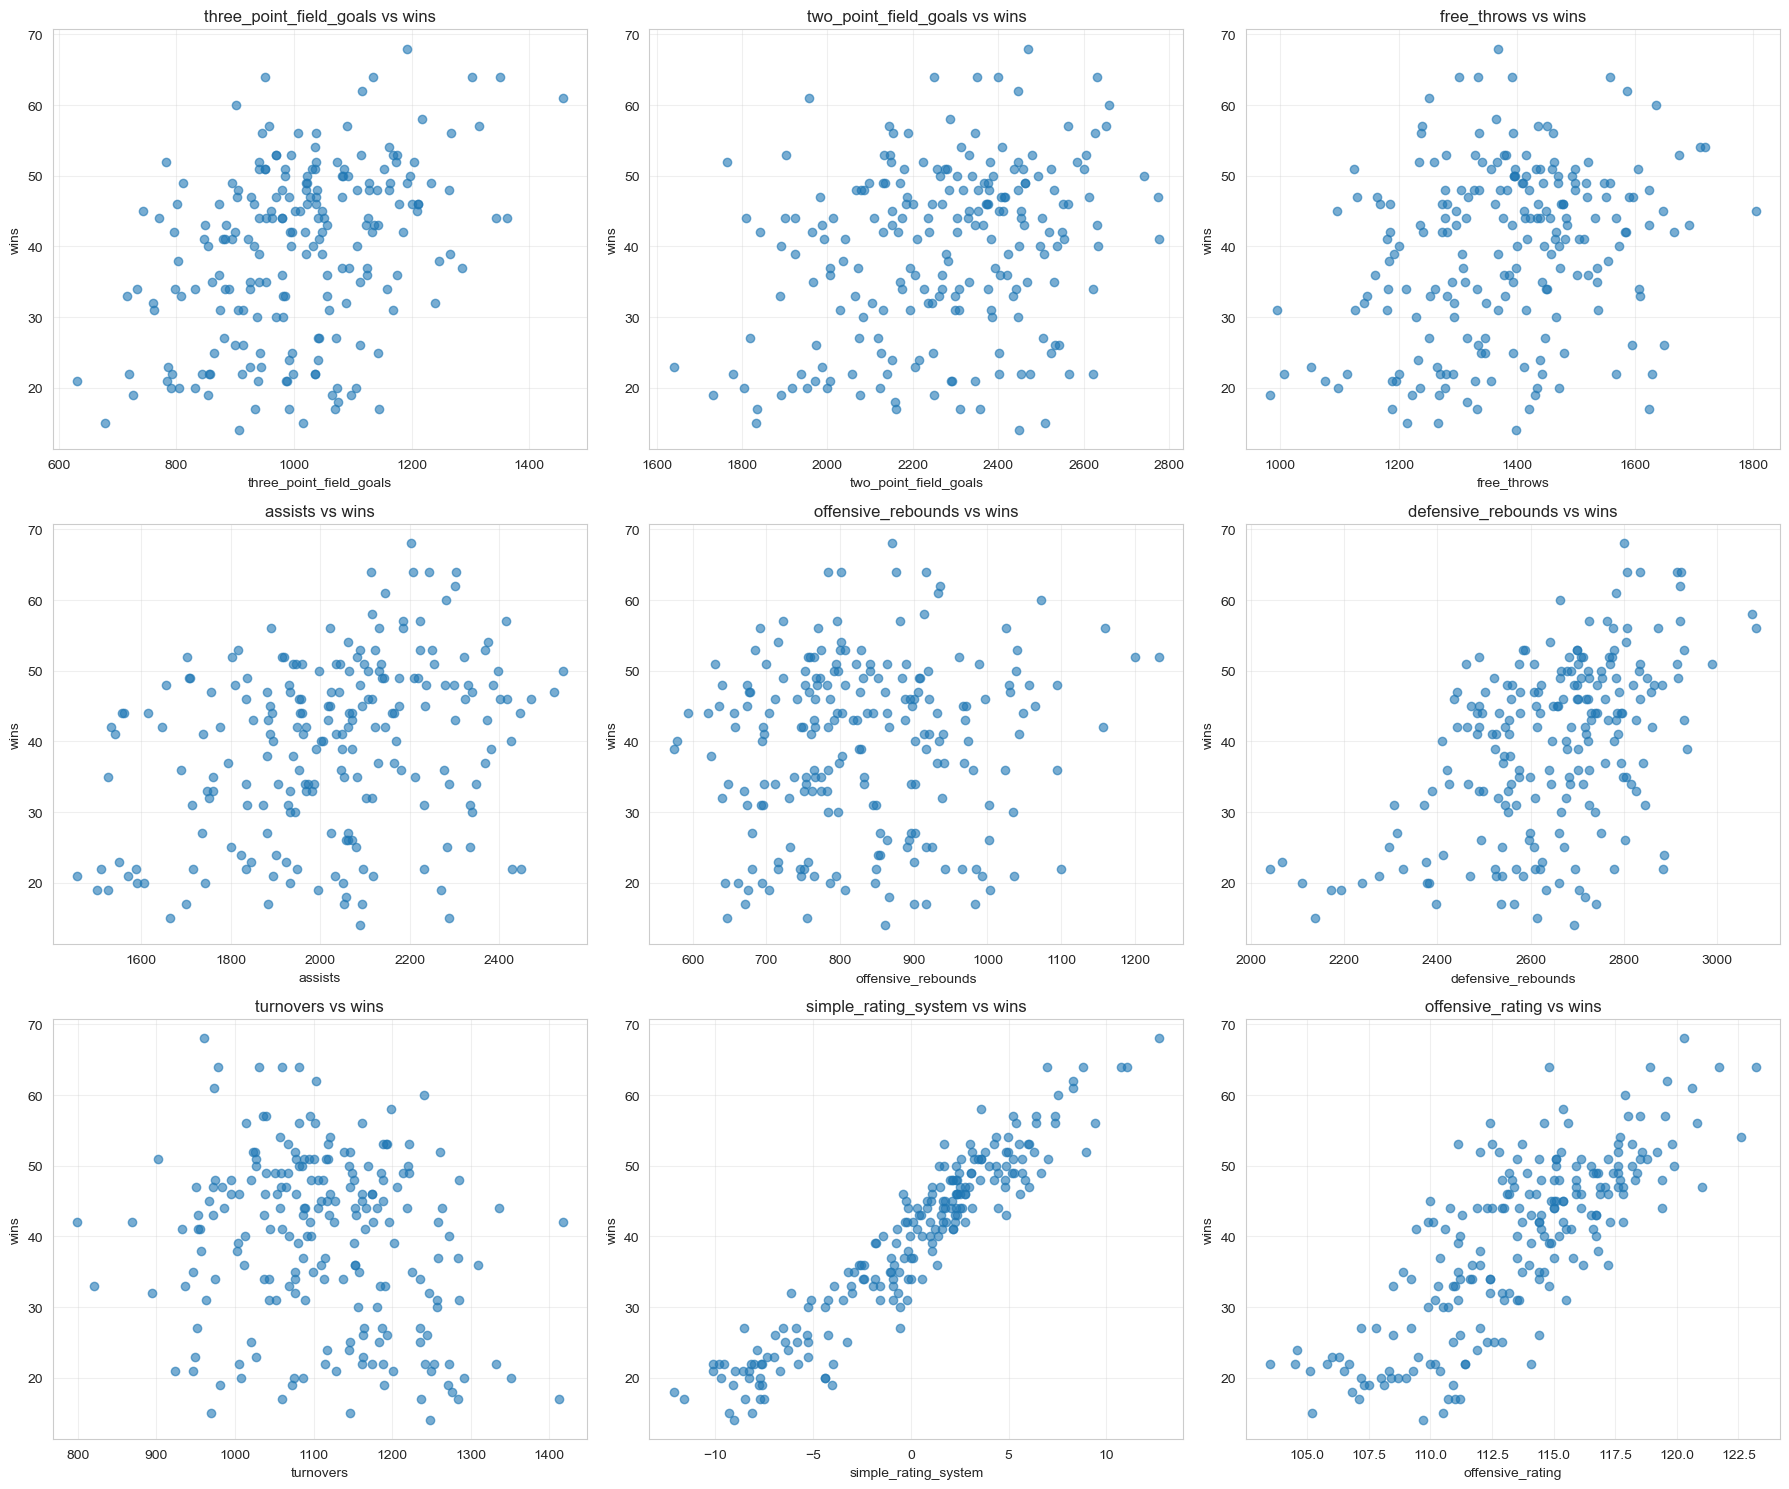

In [8]:
feature_cols = [
    "three_point_field_goals",
    "two_point_field_goals",
    "free_throws",
    "assists",
    "offensive_rebounds",
    "defensive_rebounds",
    "turnovers",
    "simple_rating_system",
    "offensive_rating"
]

plot_features_vs_wins(
    data=team_season_stats,
    feature_cols=feature_cols
)

In [9]:
def overview_numeric(df, col, k=1.5):

    data = df[col].dropna()


    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    n_lower = (data < lower).sum()
    n_upper = (data > upper).sum()

    
    shapiro_stat, p_shapiro = stats.shapiro(data)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4)
    )

    fig.suptitle(
        col,
        fontsize=14,
        fontweight="bold"
    )

    # Boxplot
    sns.boxplot(
        x=data,
        ax=axes[0]
    )

    axes[0].set_title("Boxplot")

    axes[0].text(
        0.02,
        0.90,
        f"Lower outliers: {n_lower}",
        transform=axes[0].transAxes
    )

    axes[0].text(
        0.02,
        0.80,
        f"Upper outliers: {n_upper}",
        transform=axes[0].transAxes
    )

    # Histogram
    sns.histplot(
        data,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title("Histogram + KDE")
    axes[1].set_xlabel(col)

    # Q-Q Plot
    stats.probplot(
        data,
        dist="norm",
        plot=axes[2]
    )

    axes[2].set_title(
        f"Q-Q Plot (p-value = {p_shapiro:.4f})"
    )

    plt.tight_layout()
    plt.show()

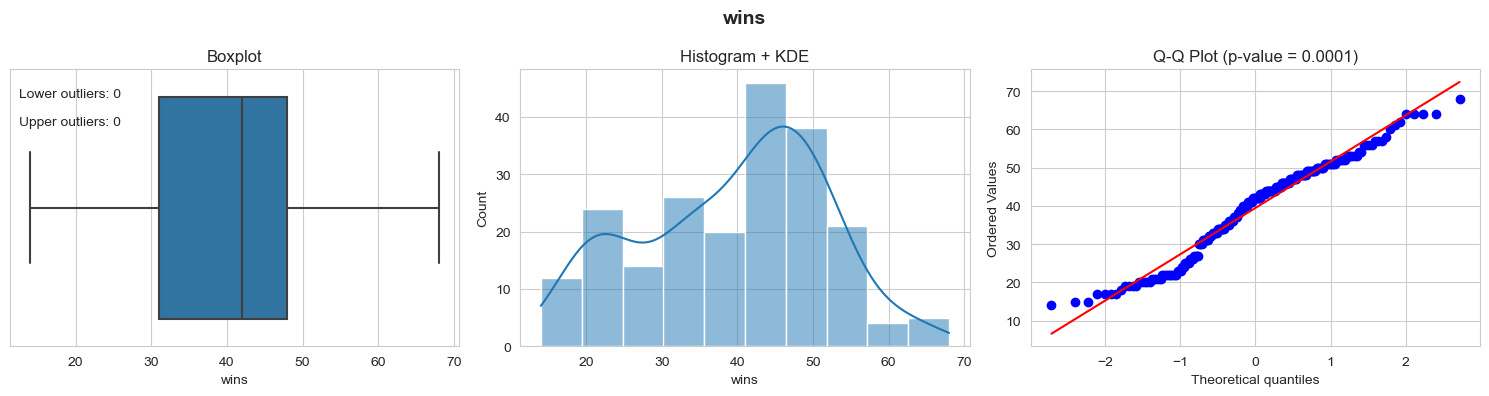

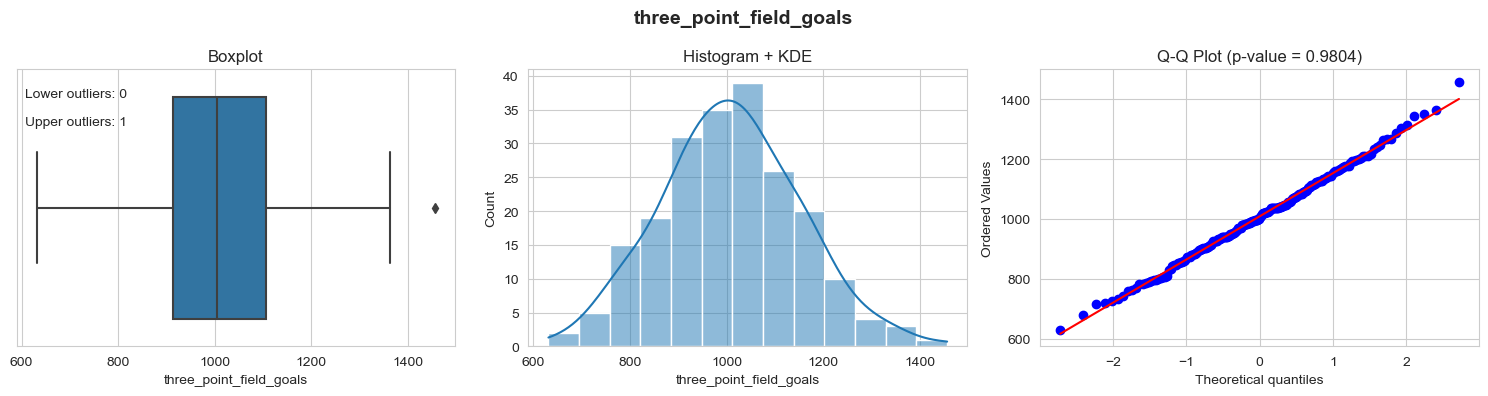

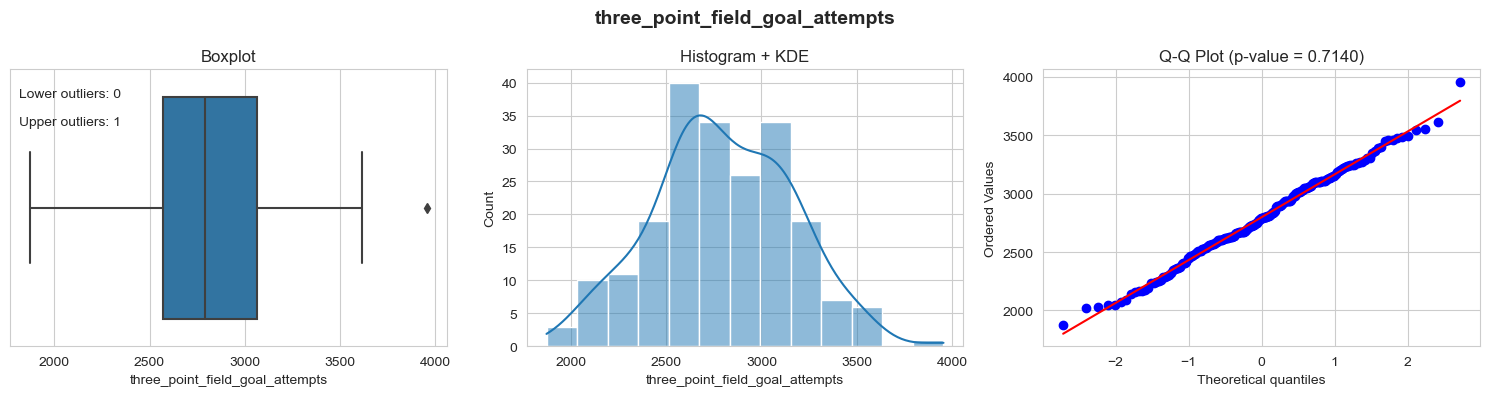

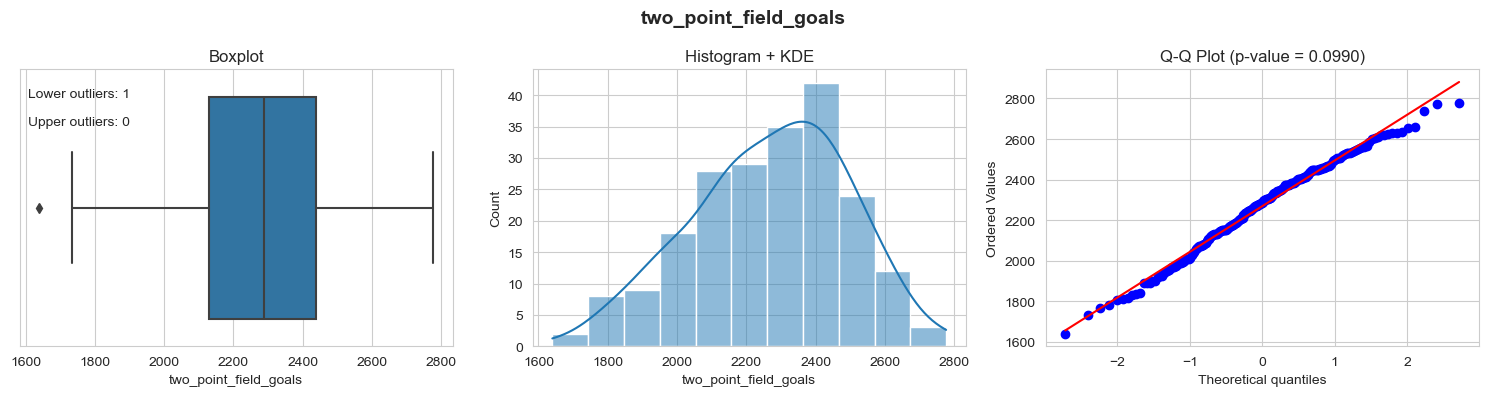

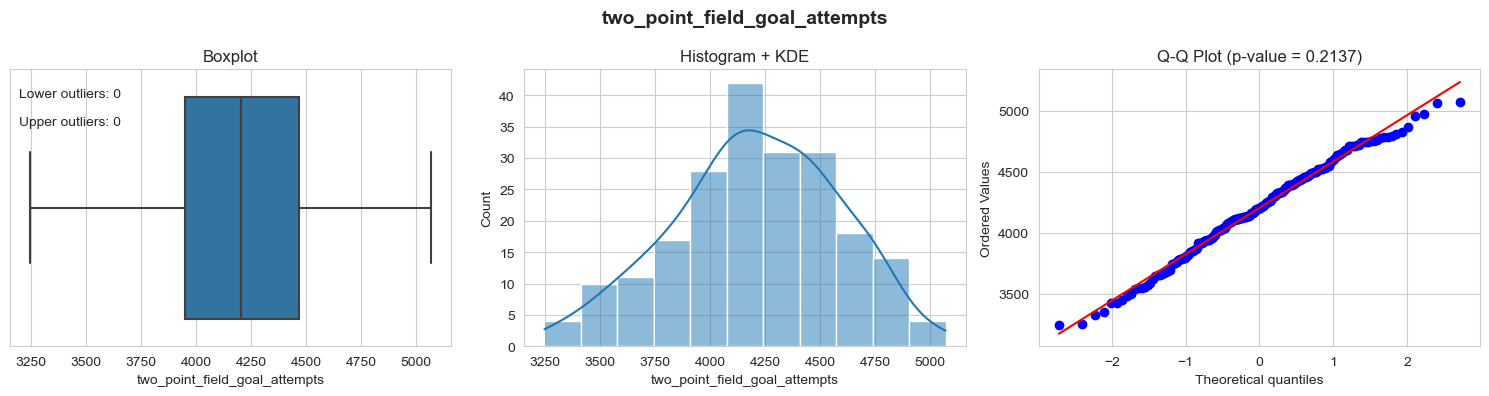

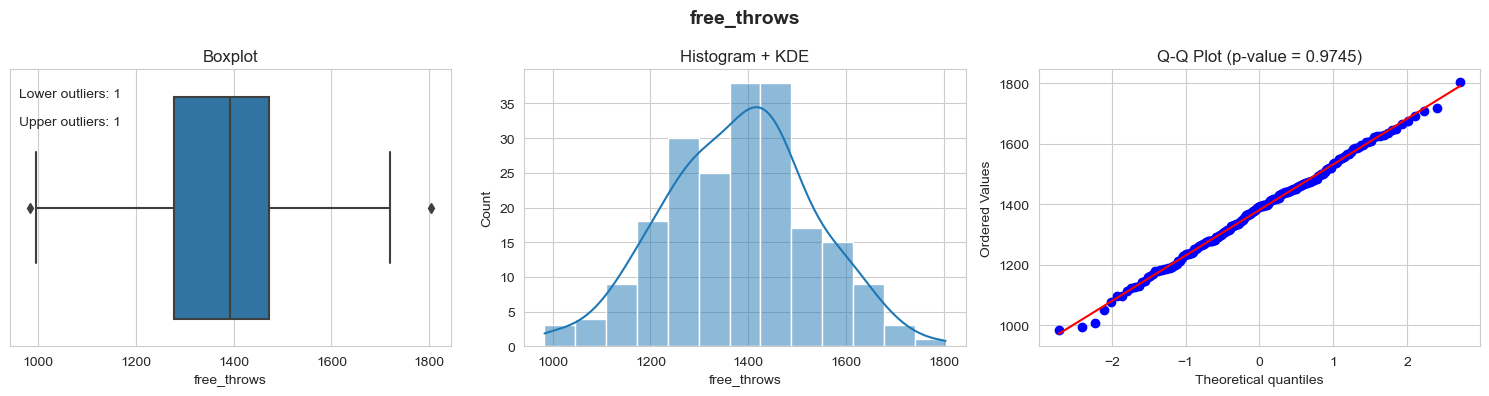

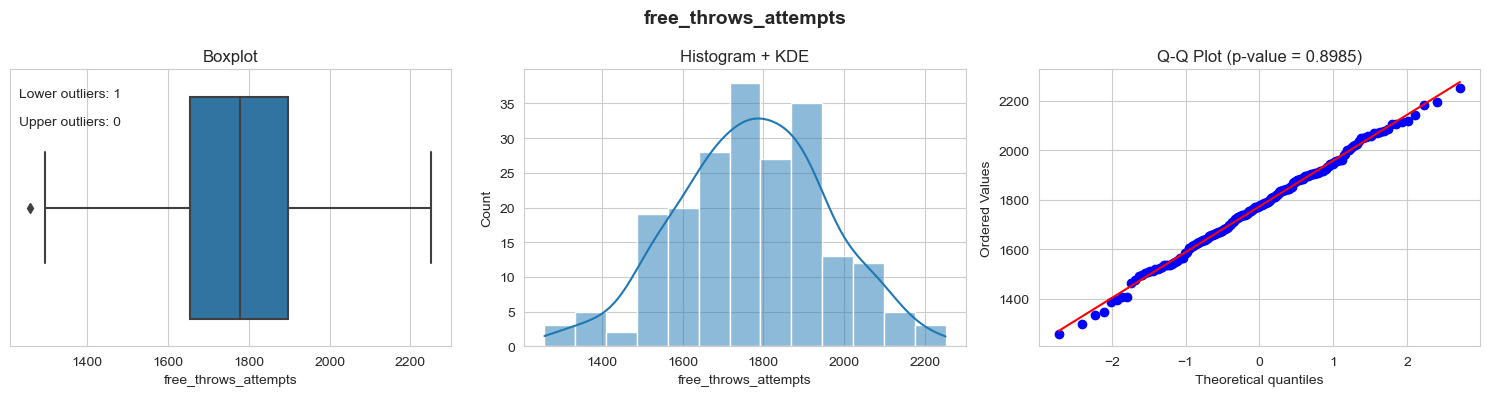

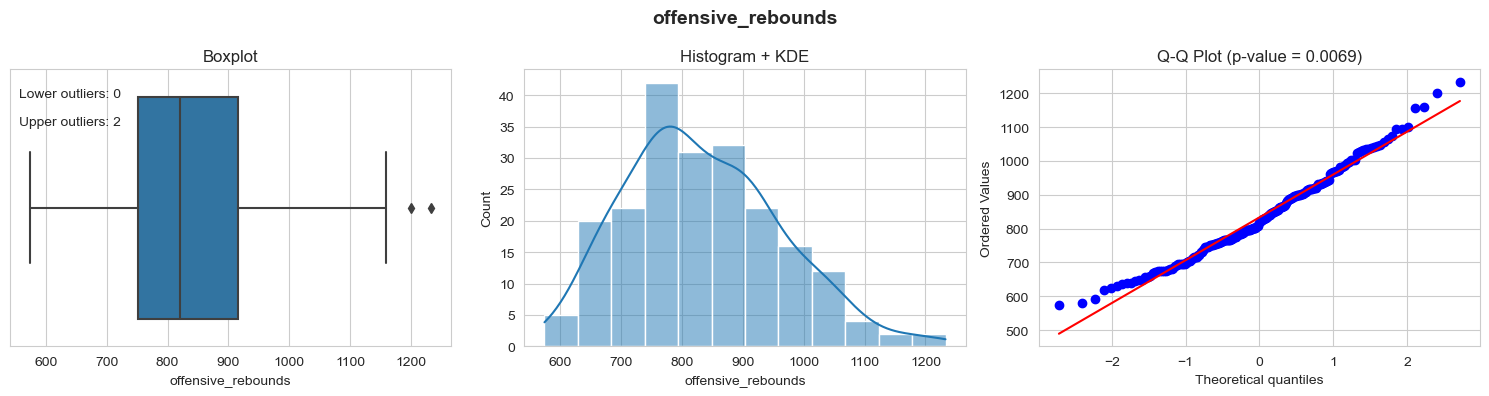

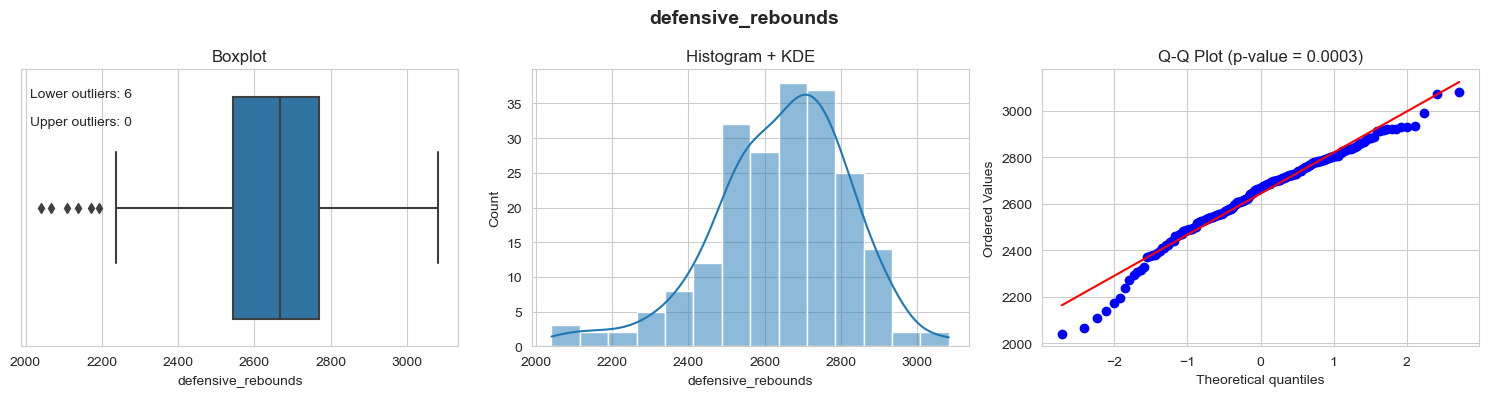

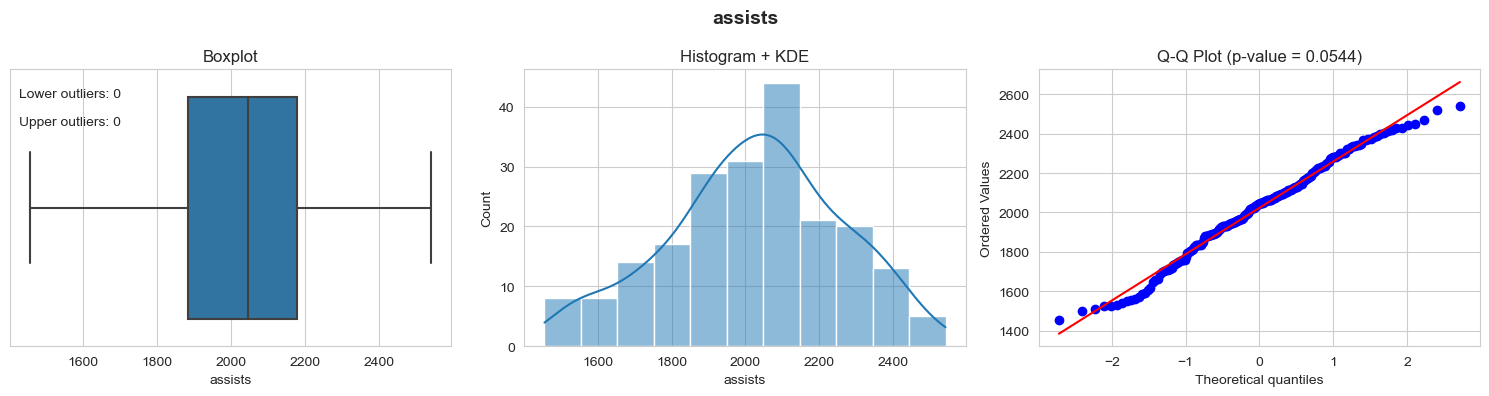

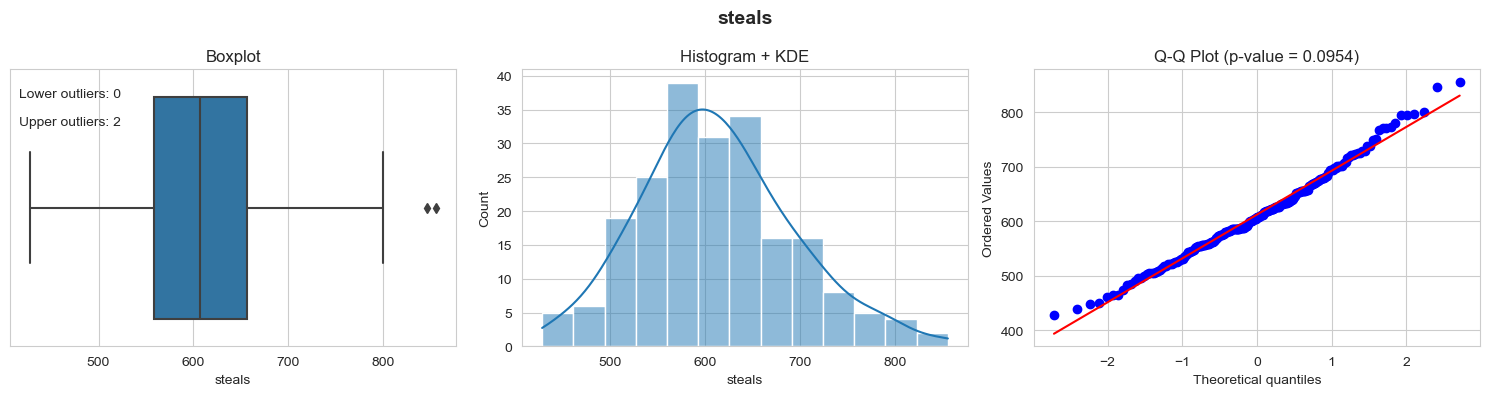

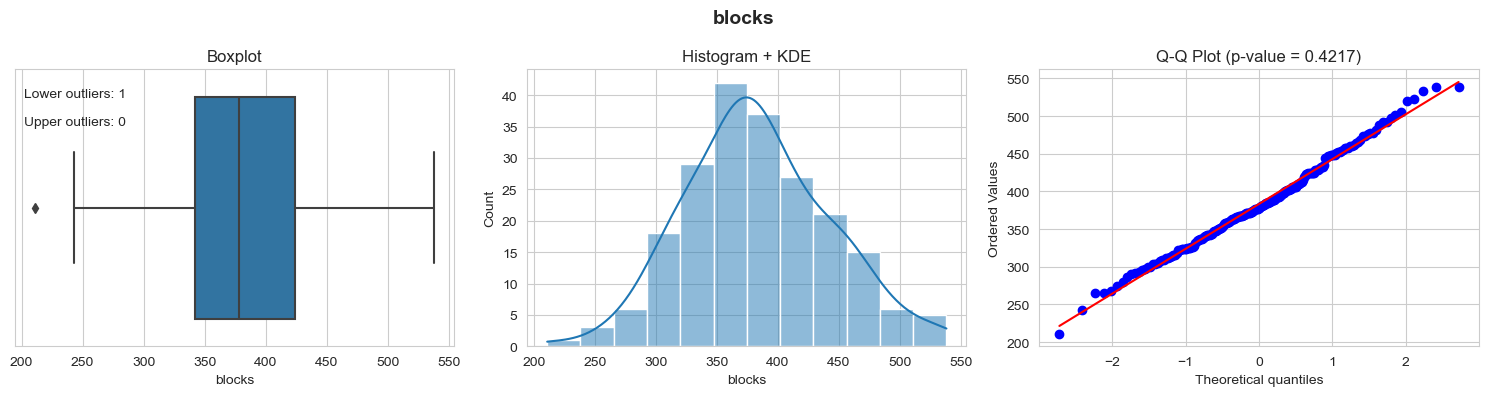

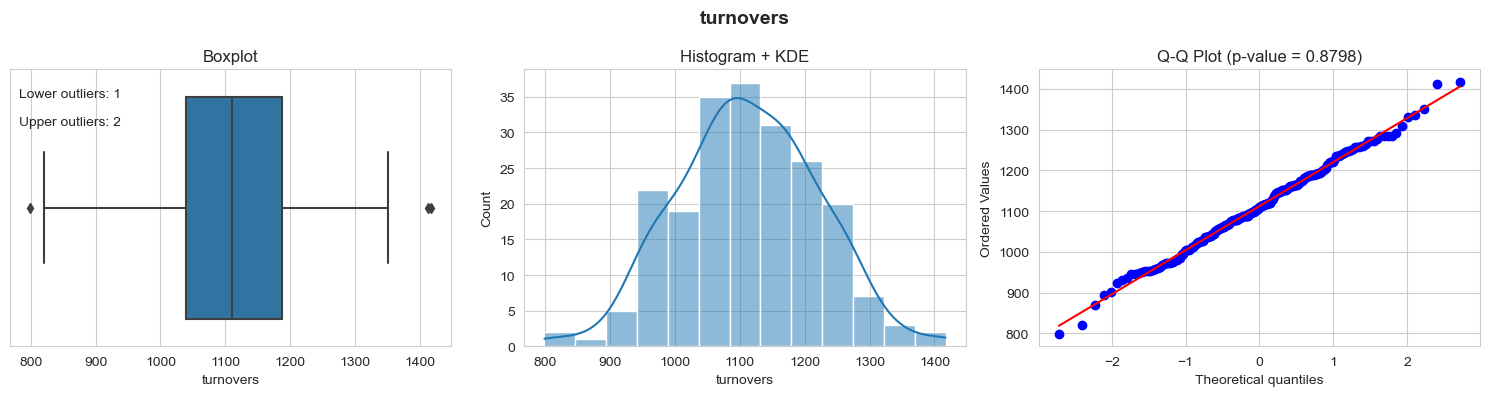

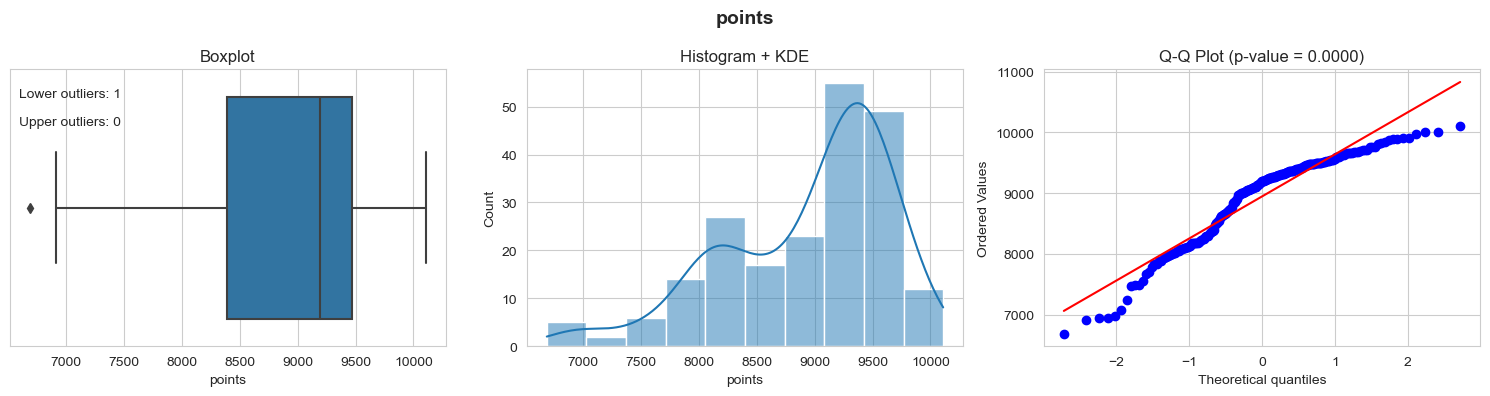

In [10]:
wanted_cols = [
    "wins",
    "three_point_field_goals",
    "three_point_field_goal_attempts",
    "two_point_field_goals",
    "two_point_field_goal_attempts",
    "free_throws",
    "free_throws_attempts",
    "offensive_rebounds",
    "defensive_rebounds",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "points"
]

for col in wanted_cols:
    overview_numeric(
        team_season_stats,
        col
    )

In [12]:
model_1 = smf.ols(
    formula="""
        wins ~
        three_point_field_goals +
        two_point_field_goals +
        free_throws +
        offensive_rebounds +
        defensive_rebounds +
        assists +
        turnovers +
        average_age
    """,
    data=team_season_stats
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     33.87
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.93e-33
Time:                        21:36:48   Log-Likelihood:                -732.78
No. Observations:                 210   AIC:                             1484.
Df Residuals:                     201   BIC:                             1514.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [13]:
model_2 = smf.ols(
    formula="""
        wins ~
        pace +
        offensive_rating +
        simple_rating_system
    """,
    data=team_season_stats
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     693.9
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          2.25e-107
Time:                        21:37:02   Log-Likelihood:                -569.63
No. Observations:                 210   AIC:                             1147.
Df Residuals:                     206   BIC:                             1161.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               17.5248 

In [14]:
model_3 = smf.ols(
    formula="""
        wins ~
        simple_rating_system +
        relative_offensive_rating
    """,
    data=team_season_stats
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     896.8
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          1.07e-102
Time:                        21:37:15   Log-Likelihood:                -584.21
No. Observations:                 210   AIC:                             1174.
Df Residuals:                     207   BIC:                             1184.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             